# N1 · 设计一个消融矩阵 + 检测交互效应 (Design an Ablation)

> 配套 9.4-L4 · **真实科研动作**: 在确定性模拟器上跑 method×noise **全因子矩阵**,
> 亲手算出**交互效应**, 并对比「如果只用 OFAT 会得出什么错误结论」。

模拟器内埋了一个真相: Robust-DPO 的好处**随噪声增大** (交互效应)。你的任务是用对的设计把它检测出来。
零算力、秒级、跨天可复现。

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import experiment as ex
print("方法:", ex.METHODS, "| 噪声水平:", ex.NOISES)

方法: ['DPO', 'Robust-DPO'] | 噪声水平: [0.0, 0.2, 0.4]


## 1. 跑全因子矩阵 (method × noise × seed)

In [2]:
runs = ex.ablation_grid(seeds=range(8))   # 2 方法 × 3 噪声 × 8 种子 = 48 次
agg = ex.aggregate(runs, by=("method", "noise"))
df = pd.DataFrame(agg)
# 摆成矩阵: 行=method, 列=noise, 值=mean
mat = df.pivot(index="method", columns="noise", values="mean").round(3)
print("win-rate 均值矩阵 (行=method, 列=noise):")
mat

win-rate 均值矩阵 (行=method, 列=noise):


noise,0.0,0.2,0.4
method,,,
DPO,0.619,0.501,0.397
Robust-DPO,0.615,0.591,0.548


## 2. 读矩阵: 行看「对噪声多敏感」, 列看「该噪声下谁赢」, 差之差看交互

In [3]:
diff = (mat.loc["Robust-DPO"] - mat.loc["DPO"]).round(3)
print("两法之差 (Robust-DPO − DPO), 按噪声:")
for nz in ex.NOISES:
    print(f"  noise={nz}: {diff[nz]:+.3f}")
print("\n→ 差距随噪声从 ~0 张开到 +0.13 : 这就是交互效应的形状 (L4)。")

两法之差 (Robust-DPO − DPO), 按噪声:
  noise=0.0: -0.004
  noise=0.2: +0.090
  noise=0.4: +0.151

→ 差距随噪声从 ~0 张开到 +0.13 : 这就是交互效应的形状 (L4)。


## 3. 量化交互效应 = 差之差 (difference-in-differences, L4 公式)

In [4]:
high, low = max(ex.NOISES), min(ex.NOISES)
interaction = diff[high] - diff[low]
print(f"高噪声({high})下两法差: {diff[high]:+.3f}")
print(f"低噪声({low})下两法差: {diff[low]:+.3f}")
print(f"交互效应 (差之差)   : {interaction:+.3f}   (非零 = 存在交互)")

高噪声(0.4)下两法差: +0.151
低噪声(0.0)下两法差: -0.004
交互效应 (差之差)   : +0.155   (非零 = 存在交互)


## 4. 画交互图 (两条线不平行 = 有交互; 平行 = 无交互)

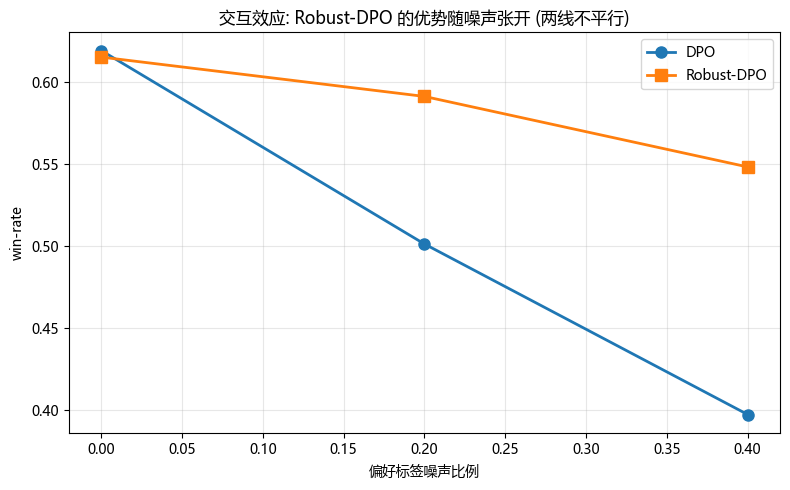

In [5]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus'] = False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, ax = plt.subplots(figsize=(8, 5))
for m, mk in zip(ex.METHODS, ["o-", "s-"]):
    ys = [mat.loc[m, nz] for nz in ex.NOISES]
    ax.plot(ex.NOISES, ys, mk, label=m, linewidth=2, markersize=8)
ax.set_xlabel("偏好标签噪声比例"); ax.set_ylabel("win-rate")
ax.set_title("交互效应: Robust-DPO 的优势随噪声张开 (两线不平行)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. 反面教材: 如果你只用 OFAT (一次只变一个因素) 会怎样

新手常犯: 只在 **noise=0** (默认/干净数据) 下比 method, 固定不动噪声。看看会得出什么结论:

In [6]:
ofat_dpo = ex.runs_for(runs, method="DPO", noise=0.0)
ofat_rob = ex.runs_for(runs, method="Robust-DPO", noise=0.0)
print(f"OFAT(只在 noise=0 比): DPO={np.mean(ofat_dpo):.3f}, Robust-DPO={np.mean(ofat_rob):.3f}")
print(f"  → 差距仅 {np.mean(ofat_rob)-np.mean(ofat_dpo):+.3f}")
print("  → OFAT 错误结论: 'Robust-DPO 没用, 别做了' ❌")
print("\n真相: 它在高噪声下高 0.13 点! OFAT 恰好踩在交互曲线的重合端, 完全错过了卖点。")
print("→ 这就是为什么必须 factorial (全因子), 而不是 OFAT。(L4 核心)")

OFAT(只在 noise=0 比): DPO=0.619, Robust-DPO=0.615
  → 差距仅 -0.004
  → OFAT 错误结论: 'Robust-DPO 没用, 别做了' ❌

真相: 它在高噪声下高 0.13 点! OFAT 恰好踩在交互曲线的重合端, 完全错过了卖点。
→ 这就是为什么必须 factorial (全因子), 而不是 OFAT。(L4 核心)


## 6. 反思

你刚做了一次完整的消融设计: 全因子矩阵 → 读行/列/差之差 → 量化并可视化交互 → 看清 OFAT 的陷阱。

**带走三件事**:
1. 交互效应 (「方法的好处取决于条件」) 比主效应 (「平均高 X 点」) 信息量大得多 —— 它给了你方法的**适用边界**, 是好论文的核心。
2. OFAT 会让你错过交互, 甚至得出反结论。**要看交互, 必须全因子。**
3. 但矩阵每格现在还只是个均值 —— 那 +0.13 有多少是种子噪声? 去 N2 用统计把它钉死。

> 真用时: 把 `experiment.py` 换成你 `dpo-family` 复现的真实训练 (run_experiment → 真训一次返回 win-rate),
> 矩阵和交互分析的代码**一行不用改**。模拟器只是让你零算力先把设计练熟。